In [ ]:
import pandas as pd
import sklearn as sk
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving diabetic_data.csv to diabetic_data.csv


In [ ]:
df=pd.read_csv('/content/diabetic_data.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [ ]:
df.tail()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,443867222,175429310,Caucasian,Male,[70-80),?,1,1,7,6,...,No,No,No,No,No,No,No,No,No,NO


In [ ]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [ ]:
df.shape

(101766, 50)

In [ ]:
df['readmitted'].value_counts()

,count
readmitted,
NO,54864
>30,35545
<30,11357


In [ ]:
df['readmitted'].value_counts(normalize=True) #normalize part convert the raw data into percentage

,proportion
readmitted,
NO,0.539119
>30,0.349282
<30,0.111599


In [ ]:
df.groupby('readmitted')['time_in_hospital'].mean()

,time_in_hospital
readmitted,
<30,4.768249
>30,4.495541
NO,4.254429


In [ ]:
df.groupby('readmitted')['num_medications'].mean()

,num_medications
readmitted,
<30,16.903143
>30,16.282768
NO,15.670367


In [ ]:
df.groupby('readmitted')['number_inpatient'].mean()

,number_inpatient
readmitted,
<30,1.224003
>30,0.838993
NO,0.381963


In [ ]:
df.dtypes

,0
encounter_id,int64
patient_nbr,int64
race,object
gender,object
age,object
weight,object
admission_type_id,int64
discharge_disposition_id,int64
admission_source_id,int64
time_in_hospital,int64


In [ ]:
df.isnull().sum()

,0
encounter_id,0
patient_nbr,0
race,0
gender,0
age,0
weight,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [ ]:
(df == '?').sum()

,0
encounter_id,0
patient_nbr,0
race,2273
gender,0
age,0
weight,98569
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['insulin_encoded'] = le.fit_transform(df['insulin'])
df

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,insulin_encoded
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,NO,1
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,Up,No,No,No,No,No,Ch,Yes,>30,3
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,Yes,NO,1
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,Up,No,No,No,No,No,Ch,Yes,NO,3
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,Steady,No,No,No,No,No,Ch,Yes,NO,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,Down,No,No,No,No,No,Ch,Yes,>30,0
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,Steady,No,No,No,No,No,No,Yes,NO,2
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,Down,No,No,No,No,No,Ch,Yes,NO,0
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,Up,No,No,No,No,No,Ch,Yes,NO,3


In [ ]:
df[['insulin','insulin_encoded']].drop_duplicates()

,insulin,insulin_encoded
0,No,1
1,Up,3
4,Steady,2
12,Down,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['A1Cresult'] = le.fit_transform(df['A1Cresult'])
df
df

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,insulin_encoded
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,NO,1
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,Up,No,No,No,No,No,Ch,Yes,>30,3
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,Yes,NO,1
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,Up,No,No,No,No,No,Ch,Yes,NO,3
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,Steady,No,No,No,No,No,Ch,Yes,NO,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,Down,No,No,No,No,No,Ch,Yes,>30,0
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,Steady,No,No,No,No,No,No,Yes,NO,2
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,Down,No,No,No,No,No,Ch,Yes,NO,0
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,Up,No,No,No,No,No,Ch,Yes,NO,3


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['change'] = le.fit_transform(df['change'])
df

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,insulin_encoded
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,1,No,NO,1
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,Up,No,No,No,No,No,0,Yes,>30,3
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,1,Yes,NO,1
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,Up,No,No,No,No,No,0,Yes,NO,3
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,Steady,No,No,No,No,No,0,Yes,NO,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,Down,No,No,No,No,No,0,Yes,>30,0
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,Steady,No,No,No,No,No,1,Yes,NO,2
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,Down,No,No,No,No,No,0,Yes,NO,0
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,Up,No,No,No,No,No,0,Yes,NO,3


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['diabetesMed'] = le.fit_transform(df['diabetesMed'])
df

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,insulin_encoded
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,1,0,NO,1
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,Up,No,No,No,No,No,0,1,>30,3
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,1,1,NO,1
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,Up,No,No,No,No,No,0,1,NO,3
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,Steady,No,No,No,No,No,0,1,NO,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,Down,No,No,No,No,No,0,1,>30,0
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,Steady,No,No,No,No,No,1,1,NO,2
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,Down,No,No,No,No,No,0,1,NO,0
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,Up,No,No,No,No,No,0,1,NO,3


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['admission_type_id'] = le.fit_transform(df['admission_type_id'])
df

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,insulin_encoded
0,2278392,8222157,Caucasian,Female,[0-10),?,5,25,1,1,...,No,No,No,No,No,No,1,0,NO,1
1,149190,55629189,Caucasian,Female,[10-20),?,0,1,7,3,...,Up,No,No,No,No,No,0,1,>30,3
2,64410,86047875,AfricanAmerican,Female,[20-30),?,0,1,7,2,...,No,No,No,No,No,No,1,1,NO,1
3,500364,82442376,Caucasian,Male,[30-40),?,0,1,7,2,...,Up,No,No,No,No,No,0,1,NO,3
4,16680,42519267,Caucasian,Male,[40-50),?,0,1,7,1,...,Steady,No,No,No,No,No,0,1,NO,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,0,3,7,3,...,Down,No,No,No,No,No,0,1,>30,0
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,0,4,5,5,...,Steady,No,No,No,No,No,1,1,NO,2
101763,443854148,41088789,Caucasian,Male,[70-80),?,0,1,7,1,...,Down,No,No,No,No,No,0,1,NO,0
101764,443857166,31693671,Caucasian,Female,[80-90),?,1,3,7,10,...,Up,No,No,No,No,No,0,1,NO,3


In [ ]:
for col in ['weight', 'payer_code', 'medical_specialty', 'race']:
    if col in df.columns:
        print(col, (df[col] == '?').mean())

weight 0.9685847925633315
payer_code 0.395574160328597
medical_specialty 0.49082208203132677
race 0.022335554114340742


In [ ]:
for col in ['diag_1', 'diag_2', 'diag_3']:
    if col in df.columns:
        print(col, df[col].nunique())

diag_1 717
diag_2 749
diag_3 790


In [ ]:
df = df.drop(columns=['weight'])

In [ ]:
df = df[df['race'] != '?']

In [ ]:
df = df.drop(columns=['payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3'])
df = df[df['race'] != '?']

In [ ]:
df.shape

(99493, 45)

In [ ]:
from sklearn.model_selection import train_test_split

df['readmitted_30d'] = (df['readmitted'] == '<30').astype(int)
X = df.drop(columns=['readmitted', 'readmitted_30d'])  # all features except targets
y = df['readmitted_30d']  # your target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [ ]:
print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(74619, 44) (24874, 44)
0.11226363258687466 0.11224571842084104


In [ ]:
X_train.dtypes.value_counts()

,count
object,27
int64,17


In [ ]:
X_train.select_dtypes(include='object').columns.tolist()

['race',
 'gender',
 'age',
 'max_glu_serum',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone']

In [ ]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = X_train.select_dtypes(include='object').columns.tolist()
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    encoders[col] = le  # save it, you'll need it for X_test and later interpretation

In [ ]:
for col in categorical_cols:
    le = encoders[col]
    unseen_labels = set(X_test[col].unique()) - set(le.classes_)

    if unseen_labels:
        # Get the mode of the original string values from the training set
        original_train_col_mode = df.loc[X_train.index, col].mode()[0]
        X_test[col] = X_test[col].replace(list(unseen_labels), original_train_col_mode)

    X_test[col] = le.transform(X_test[col])

In [ ]:
for col in categorical_cols:
    if X_test[col].dtype == 'object': # Only transform if the column is still of object type
        le = encoders[col]
        unseen_labels = set(X_test[col].unique()) - set(le.classes_)

        if unseen_labels:
            # Get the mode of the original string values from the training set
            original_train_col_mode = df.loc[X_train.index, col].mode()[0]
            X_test[col] = X_test[col].replace(list(unseen_labels), original_train_col_mode)

        X_test[col] = le.transform(X_test[col])

In [ ]:
for col in categorical_cols:
    if X_test[col].dtype == 'object': # Only transform if the column is still of object type
        le = encoders[col]
        unseen_labels = set(X_test[col].unique()) - set(le.classes_)

        if unseen_labels:
            # Get the mode of the original string values from the training set
            original_train_col_mode = df.loc[X_train.index, col].mode()[0]
            X_test[col] = X_test[col].replace(list(unseen_labels), original_train_col_mode)

        X_test[col] = le.transform(X_test[col])

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

print("Tree depth:", model.get_depth())
print("Number of leaves:", model.get_n_leaves())

Tree depth: 46
Number of leaves: 9790


In [ ]:
from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_train, model.predict(X_train))
y_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 1.0
Test Accuracy: 0.804052424218059


In [ ]:
from sklearn.metrics import roc_auc_score

y_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", auc)

ROC-AUC: 0.5412462541934737


In [ ]:
param_grid = {
    'max_depth': [4, 6, 8],
    'min_samples_leaf': [10, 20],
}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=15,      # only tries 15 random combinations
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)
random_search.fit(X_train, y_train)
print(random_search.best_params_, random_search.best_score_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=15. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


{'min_samples_leaf': 20, 'max_depth': 6} 0.6559980838928074


In [ ]:
final_model = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=20,
    random_state=42
)
final_model.fit(X_train, y_train)

y_pred_final = final_model.predict(X_test)
y_proba_final = final_model.predict_proba(X_test)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_pred_final))
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba_final))
print("Tree Depth:", final_model.get_depth())
print("Leaves:", final_model.get_n_leaves())

Test Accuracy: 0.8879552946852135
Test ROC-AUC: 0.6519849076469082
Tree Depth: 6
Leaves: 58


In [ ]:
train_acc_final = accuracy_score(y_train, final_model.predict(X_train))
print("Train Accuracy (tuned):", train_acc_final)

Train Accuracy (tuned): 0.8890765086640132


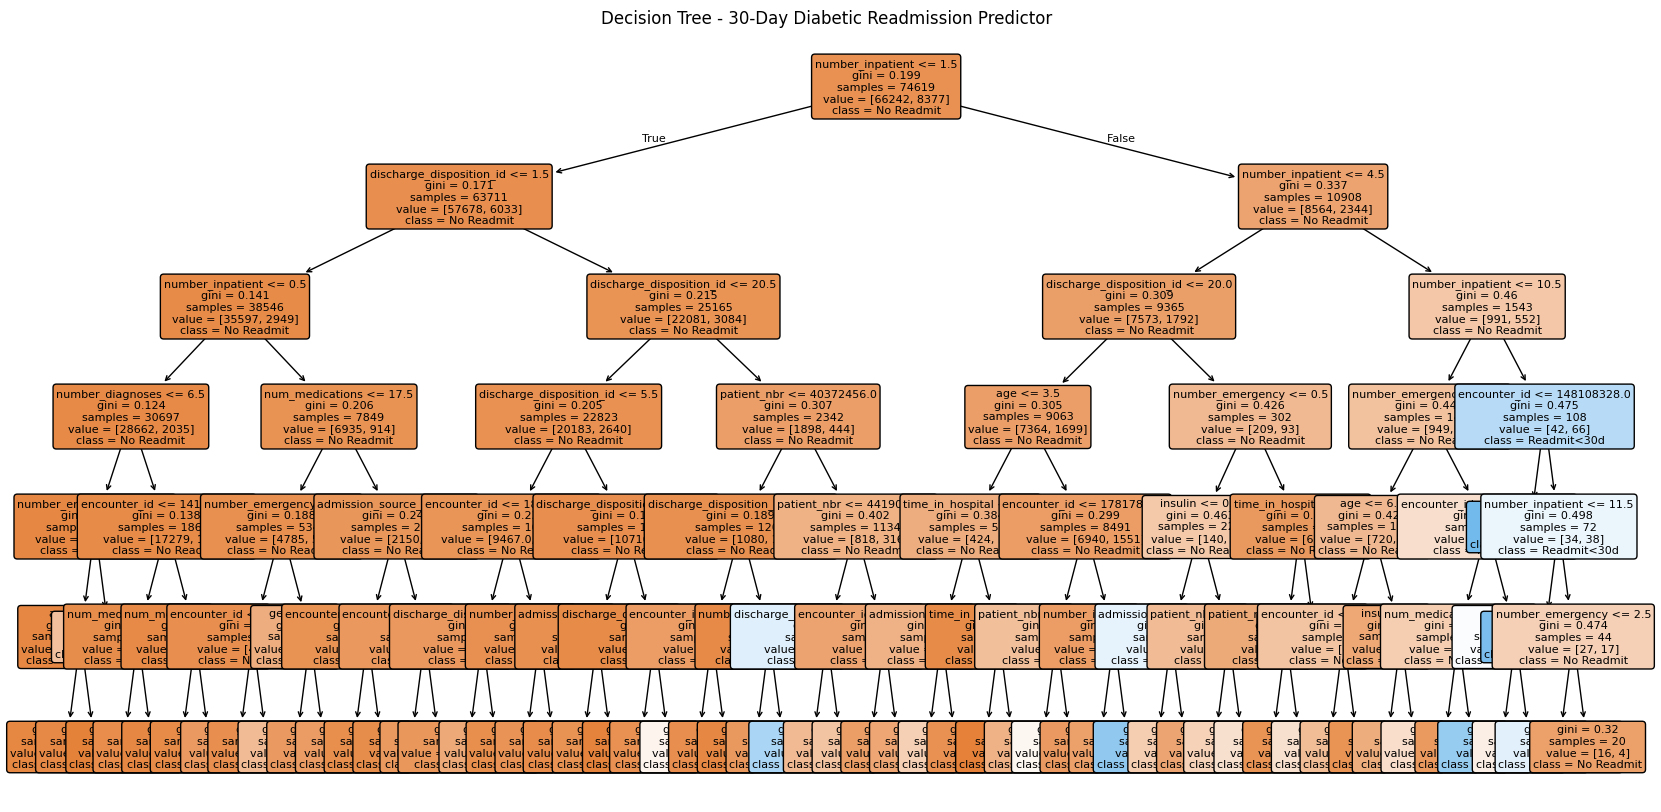

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(
    final_model,
    feature_names=X_train.columns,
    class_names=['No Readmit', 'Readmit<30d'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree - 30-Day Diabetic Readmission Predictor")
plt.savefig('tree_diagram.png', dpi=150, bbox_inches='tight')
plt.show()

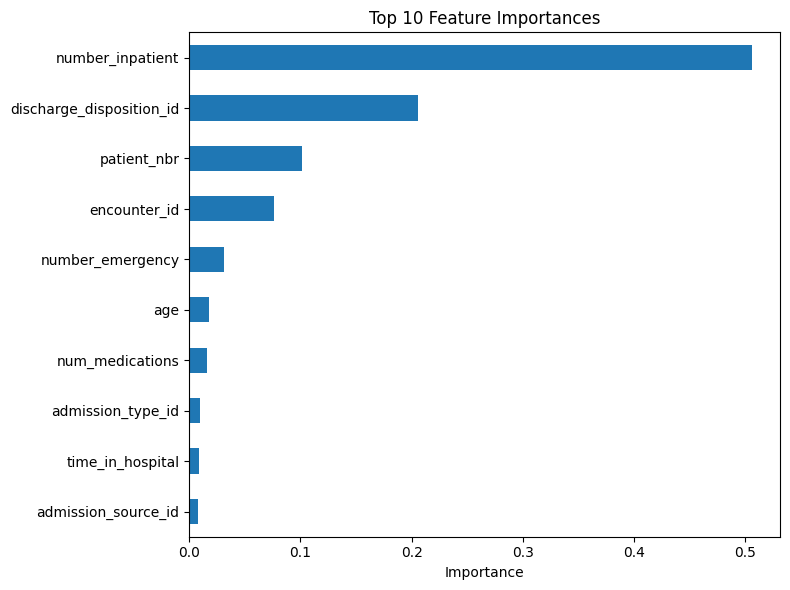

In [ ]:
import pandas as pd #features importance chart
import matplotlib.pyplot as plt

importances = pd.Series(final_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
importances.sort_values().plot(kind='barh')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

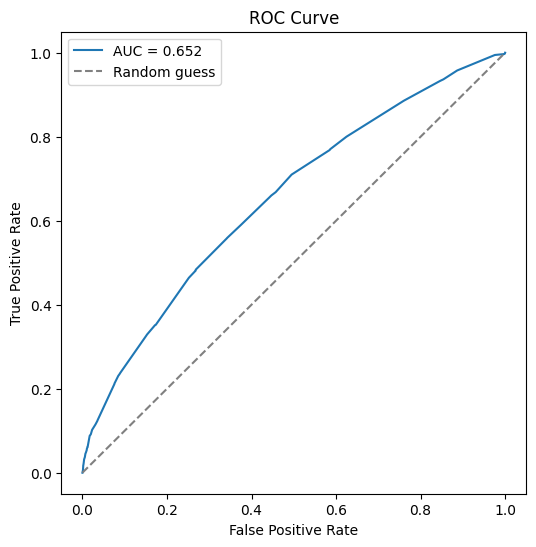

In [ ]:
from sklearn.metrics import roc_curve #roc curve

fpr, tpr, _ = roc_curve(y_test, y_proba_final)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba_final):.3f}')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

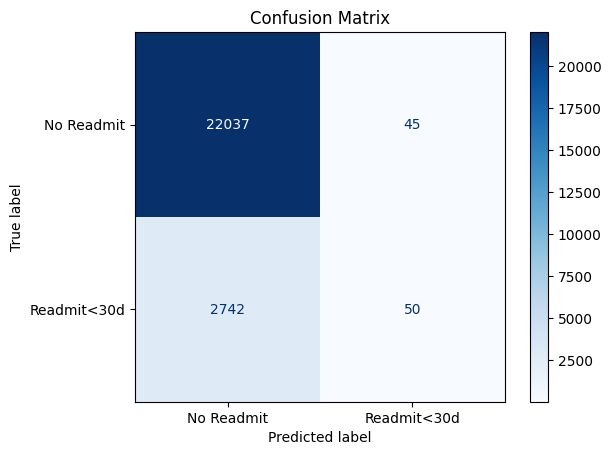

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay #confusion matrix

ConfusionMatrixDisplay.from_estimator(
    final_model, X_test, y_test,
    display_labels=['No Readmit', 'Readmit<30d'],
    cmap='Blues'
)
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

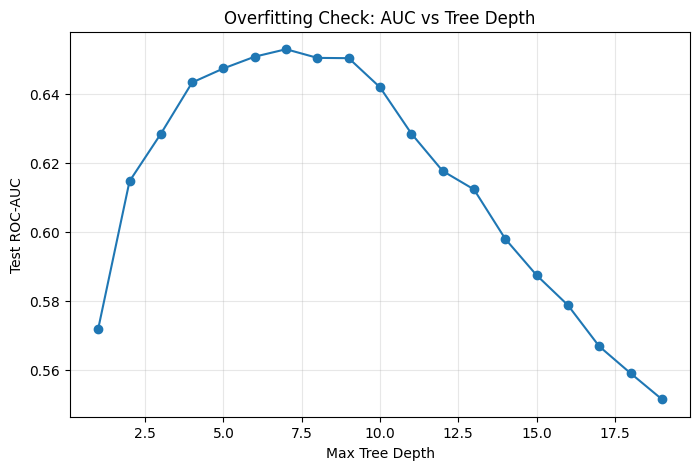

In [ ]:
depths = list(range(1, 20))
aucs = []

for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    proba = m.predict_proba(X_test)[:, 1]
    aucs.append(roc_auc_score(y_test, proba))

plt.figure(figsize=(8,5))
plt.plot(depths, aucs, marker='o')
plt.xlabel('Max Tree Depth')
plt.ylabel('Test ROC-AUC')
plt.title('Overfitting Check: AUC vs Tree Depth')
plt.grid(alpha=0.3)
plt.savefig('depth_vs_auc.png', dpi=150)
plt.show()

In [ ]:
import pickle

# Save the trained model
with open("final_model.pkl", "wb") as file:
    pickle.dump(final_model, file)

print("Model saved successfully!")

Model saved successfully!


In [ ]:
import pickle

# Save preprocessing objects if they exist

try:
    with open("label_encoders.pkl", "wb") as f:
        pickle.dump(label_encoders, f)
    print("label_encoders.pkl saved")
except:
    print("No label_encoders variable found")

try:
    with open("scaler.pkl", "wb") as f:
        pickle.dump(scaler, f)
    print("scaler.pkl saved")
except:
    print("No scaler variable found")

try:
    with open("feature_columns.pkl", "wb") as f:
        pickle.dump(X.columns.tolist(), f)
    print("feature_columns.pkl saved")
except:
        print("Could not save feature columns")

No label_encoders variable found
No scaler variable found
feature_columns.pkl saved


In [ ]:
print(X.columns.tolist())

['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'insulin_encoded']


In [ ]:
print(X.head())

   encounter_id  patient_nbr             race  gender      age  \
0       2278392      8222157        Caucasian  Female   [0-10)   
1        149190     55629189        Caucasian  Female  [10-20)   
2         64410     86047875  AfricanAmerican  Female  [20-30)   
3        500364     82442376        Caucasian    Male  [30-40)   
4         16680     42519267        Caucasian    Male  [40-50)   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  5                        25                    1   
1                  0                         1                    7   
2                  0                         1                    7   
3                  0                         1                    7   
4                  0                         1                    7   

   time_in_hospital  num_lab_procedures  ...  citoglipton  insulin  \
0                 1                  41  ...           No       No   
1                 3                 

In [ ]:
X.iloc[0]

,0
encounter_id,2278392
patient_nbr,8222157
race,Caucasian
gender,Female
age,[0-10)
admission_type_id,5
discharge_disposition_id,25
admission_source_id,1
time_in_hospital,1
num_lab_procedures,41


In [ ]:
features = [
    'race',
    'gender',
    'age',
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses',
    'A1Cresult',
    'insulin',
    'change',
    'diabetesMed'
]

X = df[features]

In [ ]:
X = df.drop('readmitted', axis=1)
y = df['readmitted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
import pickle

with open("final_model.pkl", "wb") as file:
    pickle.dump(final_model, file)

print("New model saved successfully!")

New model saved successfully!


In [ ]:
print(X.dtypes)

encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
number_diagnoses             int64
max_glu_serum               object
A1Cresult                    int64
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride                 object
acetohexamide               object
glipizide                   object
glyburide                   object
tolbutamide                 object
pioglitazone                object
rosiglitazone       

In [ ]:
print(X.columns.tolist())
print(len(X.columns))

['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'insulin_encoded', 'readmitted_30d']
45


In [ ]:
X = df.drop(columns=['readmitted'])

In [ ]:
X = df.iloc[:, :-1]

In [ ]:
import pickle

with open("final_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

print("Model saved!")

Model saved!


In [ ]:
print(X.columns.tolist())
print(len(X.columns))

['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted', 'insulin_encoded']
45


In [ ]:
import json
import os

# --- IMPORTANT: Replace 'Hospital Readmission Predictor.ipynb' with the actual filename of your notebook ---
# You might need to download your notebook (File -> Download -> Download .ipynb)
# and then upload it to the /content/ directory in Colab's file browser.
notebook_filename = 'Hospital Readmission Predictor.ipynb' # Assumed name from the original code
notebook_path = os.path.join('/content/', notebook_filename)

print(f"Attempting to open notebook: {notebook_path}")

# List files in /content/ for debugging
print("\nFiles in /content/ directory:")
try:
    for item in os.listdir('/content/'):
        print(f"  - {item}")
except Exception as e:
    print(f"Could not list /content/ directory: {e}")
print("-" * 30)

try:
    with open(notebook_path, 'r') as f:
        nb = json.load(f)

    print(f"\nSuccessfully loaded notebook: '{notebook_filename}'")

    found_assignments = False
    for i, cell in enumerate(nb['cells']):
        if cell['cell_type'] == 'code':
            source = ''.join(cell['source'])
            # Look for 'X =' or 'X=' in the code source
            if 'X =' in source or 'X=' in source:
                found_assignments = True
                print(f"\n===== Cell {i} === corroded")
                print(source)

    if not found_assignments:
        print(f"\nNo assignments to 'X =' or 'X=' found in '{notebook_filename}'.")

except FileNotFoundError:
    print(f"\nError: The notebook file '{notebook_filename}' was not found at '{notebook_path}'.")
    print("Please ensure your .ipynb file is uploaded to the /content/ directory and the 'notebook_filename' variable above matches its exact name.")
    print("If you want to analyze the *current* notebook, you typically need to download it (File -> Download -> Download .ipynb) and then upload it back to Colab's file system.")
except json.JSONDecodeError:
    print(f"\nError: Could not decode '{notebook_filename}' as a JSON file.")
    print("This usually means the file is not a valid .ipynb notebook format.")
except Exception as e:
    print(f"\nAn unexpected error occurred: {e}")

Attempting to open notebook: /content/Hospital Readmission Predictor.ipynb

Files in /content/ directory:
  - .config
  - feature_importance.png
  - diabetic_data.csv
  - final_model.pkl
  - label_encoders.pkl
  - depth_vs_auc.png
  - tree_diagram.png
  - feature_columns.pkl
  - scaler.pkl
  - Bengaluru_House_Data.csv
  - roc_curve.png
  - confusion_matrix.png
  - sample_data
------------------------------

Error: The notebook file 'Hospital Readmission Predictor.ipynb' was not found at '/content/Hospital Readmission Predictor.ipynb'.
Please ensure your .ipynb file is uploaded to the /content/ directory and the 'notebook_filename' variable above matches its exact name.
If you want to analyze the *current* notebook, you typically need to download it (File -> Download -> Download .ipynb) and then upload it back to Colab's file system.


In [ ]:
import pickle

with open("feature_columns.pkl", "rb") as f:
    feature_columns = pickle.load(f)

print(feature_columns)
print("Number of features:", len(feature_columns))

['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'insulin_encoded']
Number of features: 44


In [ ]:
import pickle
import os

file_path = "label_encoders.pkl"

if os.path.exists(file_path) and os.path.getsize(file_path) > 0:
    with open(file_path, "rb") as f:
        label_encoders = pickle.load(f)

    print(label_encoders.keys())
else:
    print(f"Error: The file '{file_path}' is either missing or empty. (EOFError: Ran out of input)\n")
    print("This usually means the `label_encoders` variable was not correctly saved to the file.\n")
    print("HINT: In a previous cell (like LY3mcPHq8dBA), you might have intended to save the `encoders` dictionary (created in ozZZ1kL88jq4) but instead attempted to save a non-existent `label_encoders` variable. Please go back and ensure the correct dictionary is saved.")



Error: The file 'label_encoders.pkl' is either missing or empty. (EOFError: Ran out of input)

This usually means the `label_encoders` variable was not correctly saved to the file.

HINT: In a previous cell (like LY3mcPHq8dBA), you might have intended to save the `encoders` dictionary (created in ozZZ1kL88jq4) but instead attempted to save a non-existent `label_encoders` variable. Please go back and ensure the correct dictionary is saved.


In [ ]:
import pickle

with open("feature_columns.pkl", "rb") as f:
    feature_columns = pickle.load(f)

print(type(feature_columns))
print(feature_columns)
print("Total features:", len(feature_columns))

<class 'list'>
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'insulin_encoded']
Total features: 44


In [ ]:
import pickle
import os

file_path = "label_encoders.pkl"

if os.path.exists(file_path) and os.path.getsize(file_path) > 0:
    with open(file_path, "rb") as f:
        label_encoders = pickle.load(f)

    print(type(label_encoders))
    print(label_encoders)
else:
    print(f"Error: The file '{file_path}' is either missing or empty. (EOFError: Ran out of input)\n")
    print("This usually means the `label_encoders` variable was not correctly saved to the file.\n")
    print("HINT: In a previous cell (like LY3mcPHq8dBA), you might have intended to save the `encoders` dictionary (created in ozZZ1kL88jq4) but instead attempted to save a non-existent `label_encoders` variable. Please go back and ensure the correct dictionary is saved.")

Error: The file 'label_encoders.pkl' is either missing or empty. (EOFError: Ran out of input)

This usually means the `label_encoders` variable was not correctly saved to the file.

HINT: In a previous cell (like LY3mcPHq8dBA), you might have intended to save the `encoders` dictionary (created in ozZZ1kL88jq4) but instead attempted to save a non-existent `label_encoders` variable. Please go back and ensure the correct dictionary is saved.


In [ ]:
import pandas as pd

df = pd.read_csv("diabetic_data.csv")

print(df.shape)
print(df.columns.tolist())

(101766, 50)
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']
